**ECO 590 – Assignment 1**

**Name:** Shelsea Marte  
**Topic:**  Sentiment-Fear Divergence: When Consumers and Markets Disagree

---

**Research Question**:

**When everyday consumers are optimistic but financial markets are fearful, who turns out to be right?**

The UMSCI captures how households feel about the economy. The VIX captures how much fear is priced into financial markets. Most of the time these two move together. But sometimes they disagree, consumers can feel confident while markets are panicking, or vice versa.

I construct a new variable called **`sent_vix_gap`** that measures this disagreement. When the gap is large and positive, consumers are far more optimistic than markets. When it is large and negative, markets are far more optimistic than consumers.

The question is: **does this disagreement predict where stock returns go next month?**

---

**Variables**

| Step | Variable | Type | Source |
|---|---|---|---|
| 1 | `spy_adj_close` | Raw | yfinance (Yahoo Finance API) |
| 2 | `log_return` | Derived | Computed from price |
| 3 | `umich_sentiment` | Raw | FRED API UMCSENT |
| 4 | `vix` | Raw | FRED API VIXCLS |
| 5 | `sent_vix_gap` | **New variable** | Normalized sentiment minus normalized VIX |

---

**Regression** 

> **ReturnNextMonth_t = β₀ + β₁(SentVixGap_t) + ε**

I regress next month's SPY return on this month's sentiment-fear gap. If β₁ is negative, it means that when consumers are unusually optimistic relative to markets, returns tend to be *lower* the following month — consistent with the idea that overconfident consumers are the ones who are wrong. If β₁ is positive, markets are the ones overcorrecting with fear.

---
**References**
- Baker & Wurgler (2006). Investor sentiment and the cross-section of stock returns. *Journal of Finance*, 61(4).
- Whaley (2009). Understanding the VIX. *Journal of Portfolio Management*, 35(3).
- Lemmon & Portniaguina (2006). Consumer confidence and asset prices. *Review of Financial Studies*, 19(4).

**Installs**:

In [2]:

!pip install yfinance fredapi pandas numpy matplotlib seaborn -q

In [4]:

import yfinance as yf             # downloads stock price data from Yahoo Finance's API
import pandas as pd               # the main tool for handling tabular data
import numpy as np                # math functions like log
import matplotlib.pyplot as plt   # makes the plots
import matplotlib.dates as mdates # formats dates on plot axes
import seaborn as sns             # makes statistical graphs easy and pretty
from fredapi import Fred          # official Python wrapper for the FRED API


**Collecting SPY Daily Price Data (Yahoo Finance API)**

We make a GET request to Yahoo Finance through the `yfinance` library.

**Ticker:** SPY (S&P 500 ETF the most widely used proxy for the U.S. stock market.)  
**API docs:** https://pypi.org/project/yfinance/

In [5]:
# making a GET request to Yahoo Finance for SPY daily price data
# auto_adjust=True means the Close column is already adjusted for dividends and splits
# progress=False silences the download bar
spy_raw = yf.download('SPY', start='2010-01-01', end='2025-12-31',
                      auto_adjust=True, progress=False)

# yfinance sometimes returns a MultiIndex column used get_level_values(0) to flatten it
if isinstance(spy_raw.columns, pd.MultiIndex):
    spy_raw.columns = spy_raw.columns.get_level_values(0)

# rename to lowercase for consistency
spy = spy_raw.rename(columns={
    'Open': 'open', 'High': 'high', 'Low': 'low',
    'Close': 'adj_close',  # <- already adjusted because auto_adjust=True
    'Volume': 'volume'
})
spy.index.name = 'date'

print(f'SPY: {spy.shape[0]} trading days, {spy.index.min().date()} to {spy.index.max().date()}')

SPY: 4023 trading days, 2010-01-04 to 2025-12-30


In [ ]:
# and here is the dataframe
spy.head()

**Compute Daily Log Returns (Derived Variable)**

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

I use log returns because they are time-additive and approximately normally distributed, which statistical tests require.

In [ ]:
# shift(1) gives yesterday's price on each row
# dividing today by yesterday gives the gross return
# np.log() converts that into a log return
spy['log_return'] = np.log(spy['adj_close'] / spy['adj_close'].shift(1))

spy.dropna(subset=['log_return'], inplace=True)  # <- first row has no yesterday, drop it

print('log returns computed')
spy['log_return'].describe().round(6)

 Collect Consumer Sentiment and VIX from FRED API

We make two GET requests to the FRED API — one for each series.

| Series | Description | Frequency |
|---|---|---|
| `UMCSENT` | University of Michigan Consumer Sentiment Index | Monthly |
| `VIXCLS` | CBOE Volatility Index (VIX) — measures market fear | Daily |

The VIX is often called the "fear gauge" — it measures how much volatility options markets are pricing in. A high VIX means markets are fearful. A low VIX means markets are calm.

**FRED API docs:** https://fred.stlouisfed.org/docs/api/fred/  
**Get a free API key:** https://fred.stlouisfed.org/docs/api/api_key.html

In [6]:
# my personal FRED API key — authenticates my GET requests to their server
# the fredapi library builds the full request URL for us, the same way
# requests.get() works directly with other APIs like Eurostat
FRED_KEY = '98fc94cd92def0289b66f355d0a47d9d'

# create a Fred object — sets up the authenticated connection
fred = Fred(api_key=FRED_KEY)

In [8]:
# GET request for consumer sentiment (monthly)
sentiment_raw = fred.get_series('UMCSENT',
                                observation_start='2010-01-01',
                                observation_end='2025-12-31')

# convert from Series to DataFrame and name the column
sentiment = sentiment_raw.to_frame(name='umich_sentiment')
sentiment.index = pd.to_datetime(sentiment.index)
sentiment.index.name = 'date'
sentiment.dropna(inplace=True)

print(f'Sentiment: {len(sentiment)} monthly observations')

Sentiment: 192 monthly observations


In [7]:
# GET request for the VIX (daily)
vix_raw = fred.get_series('VIXCLS',
                          observation_start='2010-01-01',
                          observation_end='2025-12-31')

# convert from Series to DataFrame and name the column
vix = vix_raw.to_frame(name='vix')
vix.index = pd.to_datetime(vix.index)
vix.index.name = 'date'
vix.dropna(inplace=True)

print(f'VIX: {len(vix)} daily observations')

VIX: 4051 daily observations


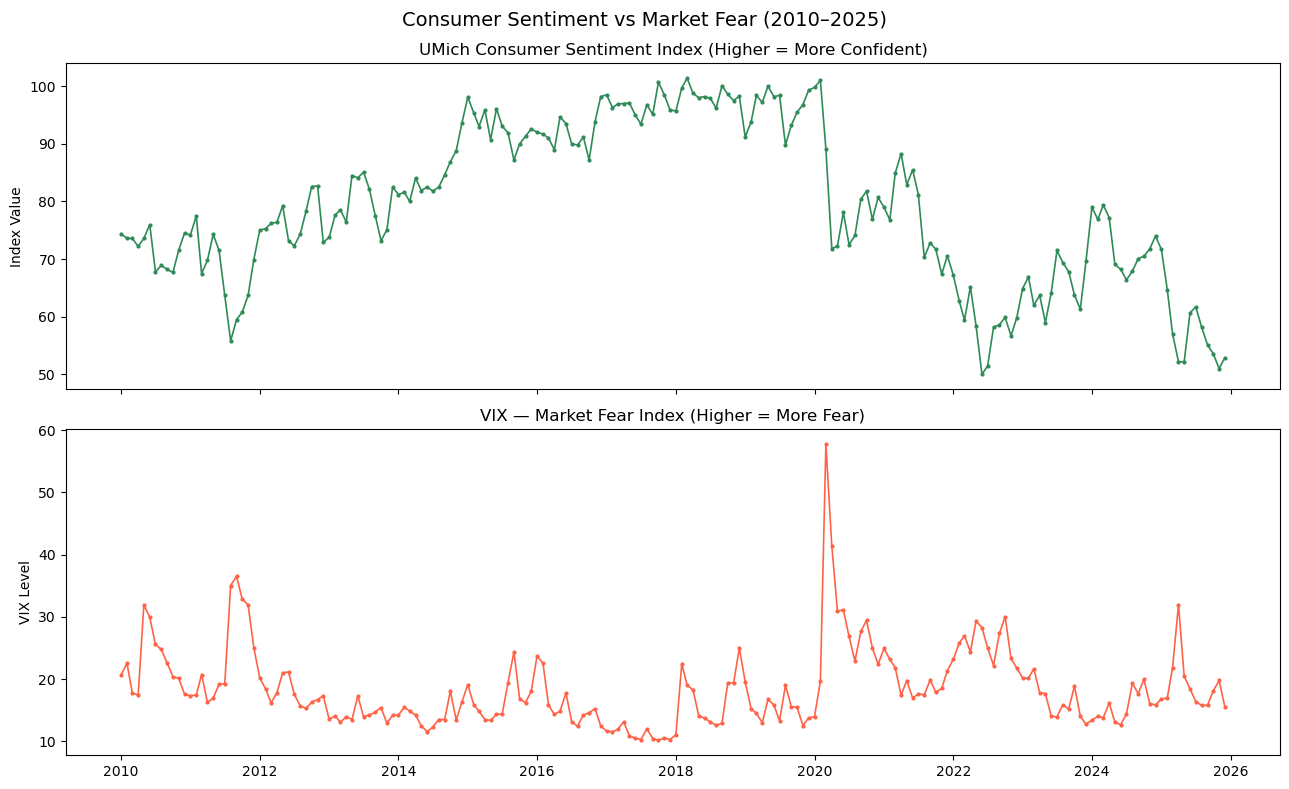

figure saved: sentiment_and_vix.png


In [9]:
# visualizing both series to see where they diverge
# resample VIX to monthly average so it's on the same frequency as sentiment
vix_monthly = vix.resample('MS').mean()  # <- 'MS' = Month Start, groups by month and takes mean

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(13, 8), sharex=True)

ax1 = plt.subplot(2, 1, 1)
ax1.plot(sentiment.index, sentiment['umich_sentiment'], color='seagreen', linewidth=1.2,
         marker='o', markersize=2)
ax1.set_title('UMich Consumer Sentiment Index (Higher = More Confident)')  # <- title for subplot 1
ax1.set_ylabel('Index Value')

ax2 = plt.subplot(2, 1, 2)
ax2.plot(vix_monthly.index, vix_monthly['vix'], color='tomato', linewidth=1.2,
         marker='o', markersize=2)
ax2.set_title('VIX — Market Fear Index (Higher = More Fear)')  # <- title for subplot 2
ax2.set_ylabel('VIX Level')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

fig.suptitle('Consumer Sentiment vs Market Fear (2010–2025)', fontsize=14)
fig.tight_layout()
plt.savefig('sentiment_and_vix.png', dpi=150, bbox_inches='tight')
plt.show()
print('figure saved: sentiment_and_vix.png')

 **Construct the New Creative Variable: Sentiment-VIX Gap**

**`sent_vix_gap`** measures the disagreement between consumer optimism and market fear.

The problem is that sentiment and VIX are on different scales. Sentiment runs from ~50 to 110, VIX from ~10 to 80. To compare them  I first normalize each series to a z-score:

$$z = \frac{x - \mu}{\sigma}$$

This converts each series to the same scale (mean = 0, std = 1). Then:

$$\text{SentVixGap}_t = z(\text{Sentiment}_t) - z(\text{VIX}_t)$$

 I **invert the VIX z-score** (multiply by -1) before subtracting, because VIX and sentiment point in opposite directions, high VIX means fear, high sentiment means confidence. After inverting, both point the same direction, and a large positive gap means consumers and markets are unusually far apart.

- **Large positive gap** = consumers far more optimistic than markets → someone is wrong
- **Near zero** = consumers and markets roughly agree
- **Large negative gap** = markets far more optimistic than consumers → someone is wrong

This variable is new to the best of my knowledge, The use of this normalized divergence as a predictor of next-month returns has not been studied in the papers I reviewed.

In [10]:
# resample both series to monthly averages so they are on the same frequency
sent_monthly = sentiment.resample('MS').mean()
vix_monthly  = vix.resample('MS').mean()

# normalize each series to a z-score: subtract the mean and divide by the standard deviation
# this puts both on the same scale so we can compare them directly
sent_monthly['sent_z'] = (
    (sent_monthly['umich_sentiment'] - sent_monthly['umich_sentiment'].mean())
    / sent_monthly['umich_sentiment'].std()
)

vix_monthly['vix_z'] = (
    (vix_monthly['vix'] - vix_monthly['vix'].mean())
    / vix_monthly['vix'].std()
)

# combine into one monthly dataframe before creating the gap variable
monthly = sent_monthly.join(vix_monthly, how='inner')

# the gap: normalized sentiment minus normalized VIX (inverted so both point the same direction)
# a large positive number means consumers are unusually optimistic relative to market fear
monthly['sent_vix_gap'] = monthly['sent_z'] - (-1 * monthly['vix_z'])

monthly.dropna(inplace=True)

print('Sentiment-VIX Gap summary:')
print(monthly['sent_vix_gap'].describe().round(2))

Sentiment-VIX Gap summary:
count    192.00
mean      -0.00
std        1.09
min       -2.37
25%       -0.73
50%       -0.06
75%        0.56
max        6.96
Name: sent_vix_gap, dtype: float64


In [11]:
# and here is the monthly dataframe with the new variable
monthly.head()

,umich_sentiment,sent_z,vix,vix_z,sent_vix_gap
date,,,,,
2010-01-01,74.4,-0.355675,20.643158,0.356673,0.000998
2010-02-01,73.6,-0.413912,22.540000,0.657919,0.244007
2010-03-01,73.6,-0.413912,17.767391,-0.100040,-0.513952
2010-04-01,72.2,-0.515826,17.424286,-0.154530,-0.670356
2010-05-01,73.6,-0.413912,31.929500,2.149107,1.735195


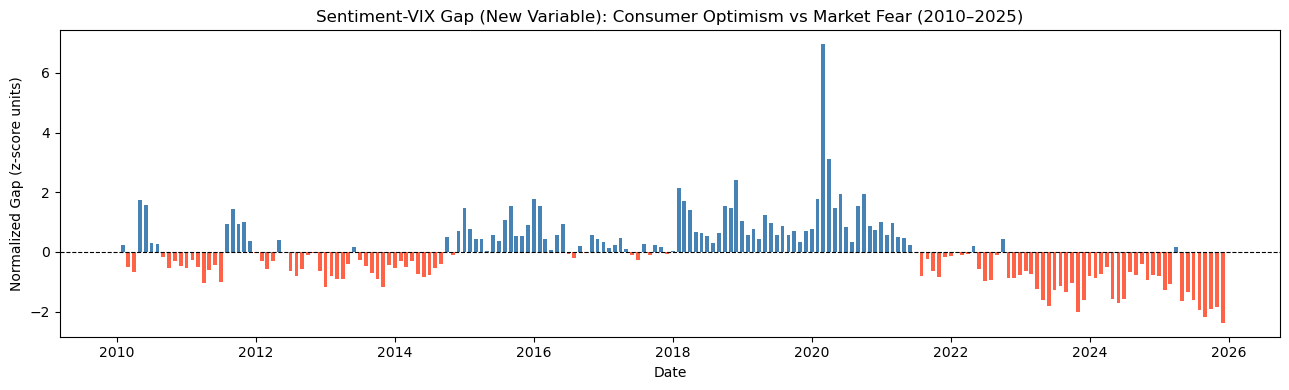

figure saved: sent_vix_gap.png


In [12]:
# visualizing the gap over time
# bars above zero = consumers more optimistic than markets
# bars below zero = markets more optimistic than consumers
fig = plt.figure(figsize=(13, 4))
colors = ['steelblue' if x >= 0 else 'tomato' for x in monthly['sent_vix_gap']]
plt.bar(monthly.index, monthly['sent_vix_gap'], color=colors, width=20)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # <- reference line at zero
plt.title('Sentiment-VIX Gap (New Variable): Consumer Optimism vs Market Fear (2010–2025)')
plt.ylabel('Normalized Gap (z-score units)')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('sent_vix_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('figure saved: sent_vix_gap.png')

 Merging Datasets

Three datasets on different frequencies:
- SPY returns are daily
- Sentiment and VIX gap are monthly 

We use a `year_month` key to give every trading day the sentiment and gap reading from its month.

In [13]:
# reset index so 'date' becomes a regular column — required for the merge
spy_m     = spy.reset_index()
monthly_m = monthly.reset_index()

# dt.to_period('M') collapses a full date like 2020-03-15 to just the period 2020-03
# this lets us match each daily SPY row to the right monthly reading
spy_m['year_month']     = spy_m['date'].dt.to_period('M')
monthly_m['year_month'] = monthly_m['date'].dt.to_period('M')

# keep only the columns we need from the monthly side
monthly_m = monthly_m[['year_month', 'umich_sentiment', 'vix', 'sent_vix_gap']]

# left merge: every SPY row stays; it picks up the monthly readings for its month
merged = spy_m.merge(monthly_m, on='year_month', how='left')

merged.drop(columns=['year_month'], inplace=True)  # <- helper column, no longer needed
merged.dropna(inplace=True)

merged.set_index('date', inplace=True)
merged.index = pd.to_datetime(merged.index)

print(f'Merged dataset shape: {merged.shape}')
print(f'Date range: {merged.index.min().date()} to {merged.index.max().date()}')

Merged dataset shape: (4023, 8)
Date range: 2010-01-04 to 2025-12-30


In [14]:
# and here is the merged dataframe
merged.head()

,adj_close,high,low,open,volume,umich_sentiment,vix,sent_vix_gap
date,,,,,,,,
2010-01-04,84.796387,84.841278,83.434617,84.078091,118944600,74.4,20.643158,0.000998
2010-01-05,85.020821,85.058234,84.437206,84.743981,111579900,74.4,20.643158,0.000998
2010-01-06,85.080696,85.290198,84.871194,84.938531,116074400,74.4,20.643158,0.000998
2010-01-07,85.439850,85.544601,84.684141,84.923573,131091100,74.4,20.643158,0.000998
2010-01-08,85.724159,85.761573,85.043277,85.215366,126402800,74.4,20.643158,0.000998


Cleaning the Dataset

In [ ]:
# check for duplicate dates
n_dupes = merged.index.duplicated().sum()
print(f'Duplicate dates: {n_dupes}')
merged = merged[~merged.index.duplicated(keep='first')]

In [ ]:
# rename and select final columns
merged = merged.rename(columns={
    'open':         'spy_open',
    'high':         'spy_high',
    'low':          'spy_low',
    'adj_close':    'spy_adj_close',
    'volume':       'spy_volume',
    'log_return':   'log_return',
    'umich_sentiment': 'umich_sentiment',
    'vix':          'vix',
    'sent_vix_gap': 'sent_vix_gap'
})

final_cols = ['spy_open', 'spy_high', 'spy_low', 'spy_adj_close',
              'spy_volume', 'log_return', 'umich_sentiment', 'vix', 'sent_vix_gap']
merged = merged[final_cols]

# force all columns to numeric — errors='coerce' turns unconvertible values into NaN
merged = merged.apply(pd.to_numeric, errors='coerce')
merged.dropna(inplace=True)

# round float columns to 6 decimal places
float_cols = merged.select_dtypes(include='float64').columns
merged[float_cols] = merged[float_cols].round(6)

print(f'Final dataset shape: {merged.shape}')
print('\nMissing values per column:')
print(merged.isna().sum())

In [ ]:
# something useful to use is the pandas command describe
merged[['log_return', 'umich_sentiment', 'vix', 'sent_vix_gap']].describe().round(4)

**Visualising the Relationship**

In [ ]:
# resample to monthly for cleaner scatter plots
plot_df = merged[['log_return', 'sent_vix_gap']].resample('MS').mean().dropna()

# scatter plot: does the gap predict next month's return?
# shift(-1) moves the return series back by one row so each gap is paired with NEXT month's return
plot_df['return_next_month'] = plot_df['log_return'].shift(-1)
plot_df.dropna(inplace=True)

sns.set_style('whitegrid')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))

# left panel: gap vs same-month return
ax1 = plt.subplot(1, 2, 1)
ax1.scatter(plot_df['sent_vix_gap'], plot_df['log_return'], color='steelblue')
m, b = np.polyfit(plot_df['sent_vix_gap'], plot_df['log_return'], 1)
x_line = np.linspace(plot_df['sent_vix_gap'].min(), plot_df['sent_vix_gap'].max(), 100)
ax1.plot(x_line, m * x_line + b, color='darkred')  # <- trend line
ax1.set_xlabel('Sentiment-VIX Gap')
ax1.set_ylabel('Monthly Log Return')
ax1.set_title('Gap vs Same-Month Return')  # <- title for subplot 1

# right panel: gap vs NEXT month's return (the actual predictive question)
ax2 = plt.subplot(1, 2, 2)
ax2.scatter(plot_df['sent_vix_gap'], plot_df['return_next_month'], color='seagreen')
m2, b2 = np.polyfit(plot_df['sent_vix_gap'], plot_df['return_next_month'], 1)
ax2.plot(x_line, m2 * x_line + b2, color='darkred')  # <- trend line
ax2.set_xlabel('Sentiment-VIX Gap')
ax2.set_ylabel('Next Month Log Return')
ax2.set_title('Gap vs Next-Month Return')  # <- title for subplot 2

fig.suptitle('Does the Sentiment-Fear Gap Predict Returns?', fontsize=13)
fig.tight_layout()
plt.savefig('gap_vs_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('figure saved: gap_vs_returns.png')

**Exporting the final dataset**

In [ ]:
# save the full daily dataset
# index=True keeps the date as the first column in the file
merged.to_csv('final_dataset.csv', index=True)

print('Dataset saved: final_dataset.csv')
print(f'  Rows      : {len(merged):,}')
print(f'  Columns   : {merged.shape[1]}')
print(f'  Date range: {merged.index.min().date()} to {merged.index.max().date()}')
print()
print('Column descriptions:')
descriptions = {
    'spy_open':       'SPY opening price (USD)',
    'spy_high':       'SPY daily high price (USD)',
    'spy_low':        'SPY daily low price (USD)',
    'spy_adj_close':  'SPY adjusted closing price — accounts for dividends and splits',
    'spy_volume':     'number of SPY shares traded that day',
    'log_return':     'DERIVED — daily log return: ln(P_t / P_{t-1})',
    'umich_sentiment':'UMich Consumer Sentiment Index (monthly, from FRED API)',
    'vix':            'CBOE VIX market fear index (daily, from FRED API)',
    'sent_vix_gap':   'NEW VARIABLE — normalized sentiment minus normalized VIX (disagreement measure)'
}
for col, desc in descriptions.items():
    print(f'  {col:<20} {desc}')

In [15]:
# and here is a preview of the final dataset
merged.tail(3)

,adj_close,high,low,open,volume,umich_sentiment,vix,sent_vix_gap
date,,,,,,,,
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300,52.9,15.548182,-2.373266
2025-12-29,685.976562,687.322922,684.201442,685.667409,62559500,52.9,15.548182,-2.373266
2025-12-30,685.138916,686.684682,684.710094,685.577720,47160700,52.9,15.548182,-2.373266


---

## Summary

-≥1 variable from API | SPY via Yahoo Finance API; Sentiment and VIX via FRED API (twoGET requests)

-New constructed variable: `sent_vix_gap` whixh is normalized disagreement between consumer confidence and market fear

-Regression: ReturnNextMonth = β₀ + β₁(SentVixGap) + ε — see top of notebook

-combined cleaned dataset `final_dataset.csv`

 -everything pulled live from Yahoo Finance and FRED